In [63]:
import pandas as pd
import music21 as m21
from fractions import Fraction
from harmonic_inference.data.data_types import ChordType


In [ ]:
# labels_df = pd.read_csv(
#         label_csv_path,
#         header=None,
#         names=["on", "off", "key", "degree", "type", "inv"],
#         dtype={"degree": str},
#         converters={"on": Fraction, "off": Fraction},
# )
chord_types = {
"D7": ChordType.MAJ_MIN7,
"M": ChordType.MAJOR,
"M7": ChordType.MAJ_MAJ7,
"d": ChordType.DIMINISHED,
"a": ChordType.AUGMENTED,
"d7": ChordType.DIM7,
"m": ChordType.MINOR,
"m7": ChordType.MIN_MIN7,
"Gr+6": ChordType.MAJOR,
"Fr+6": ChordType.MAJOR,
"It+6": ChordType.MAJOR,
"h7": ChordType.HALF_DIM7,
}

# example score
score = m21.converter.parse("choro_corpus/with_chords/score_4990-Menino_de_Ouro-Ernesto_Nazareth.xml")

key_changes = []  

# .flat handles the timeline alignment across all parts safely
for k in score.flat.getElementsByClass(m21.key.Key):  
    key_changes.append((k.offset, k))  

if not key_changes:
    for ks in score.flat.getElementsByClass(m21.key.KeySignature):
        # .asKey() forces '1 flat' to become an F Major Key object
        key_changes.append((ks.offset, ks.asKey()))  
  
# sort by offset  
key_changes.sort(key=lambda x: x[0])  
  
# Function to get key at a given offset  
def get_key_at_offset(offset):  
    for ks_offset, k_obj in reversed(key_changes):  
        if offset >= ks_offset:  
            # k_obj is now a Key object, so it has a .tonic (Note) and .mode ('major'/'minor')
            tonic_name = k_obj.tonic.name # e.g., 'C', 'F', 'G#'
            mode = k_obj.mode
            # Convert to required format: upper case for major, lower for minor  
            key_str = tonic_name.upper() if mode == 'major' else tonic_name.lower()  
            
            # replace flats/sharps with b/+  
            key_str = key_str.replace('-', 'b').replace('#', '+')  
            return key_str  
            
    return "C"  # default

rows = []  
# Using .flat here ensures the Harmony offsets match the Key offsets 
for harmony in score.flat.getElementsByClass("Harmony"):  
    on_before = None
    on = Fraction(harmony.offset)
    off = Fraction(on + harmony.duration.quarterLength)


    key = get_key_at_offset(on)
    rows.append([on, off, key])

df = pd.DataFrame(rows)

# shift to get chord offset position 
df[1] = df[0].shift(-1)

df
# Disambiguate between major and minor (A-major; fsharp-minor, etc.)
# TBD: "degree", "type", "inv"



,0,1,2
0,1,3,A
1,3,5,A
2,5,7,A
3,7,9,A
4,9,11,A
...,...,...,...
64,117,118,D
65,118,119,D
66,119,120,D
67,120,121,D


In [ ]:
chord_types = {
"dominant-seventh": ChordType.MAJ_MIN7,
"major": ChordType.MAJOR,
"major-seventh": ChordType.MAJ_MAJ7,
"diminished": ChordType.DIMINISHED,
"augmented": ChordType.AUGMENTED,
"diminshed-seventh": ChordType.DIM7,
"minor": ChordType.MINOR,
"minor-seventh": ChordType.MIN_MIN7,
"Gr+6": ChordType.MAJOR,
"Fr+6": ChordType.MAJOR,
"It+6": ChordType.MAJOR,
"half-diminished-seventh": ChordType.HALF_DIM7,
}

key_changes = []  

for k in score.flat.getElementsByClass(m21.key.Key):  
    key_changes.append((k.offset, k))  

if not key_changes:
    for ks in score.flat.getElementsByClass(m21.key.KeySignature):
        key_changes.append((ks.offset, ks.asKey()))  
  
key_changes.sort(key=lambda x: x[0])  

# return the actual music21 Key object, not just the string
def get_key_obj_at_offset(offset):  
    for ks_offset, k_obj in reversed(key_changes):  
        if offset >= ks_offset:  
            return k_obj
    return m21.key.Key('C')  # C as default Key object

# format key str
def format_key_string(k_obj):
    tonic_name = k_obj.tonic.name
    mode = k_obj.mode
    key_str = tonic_name.upper() if mode == 'major' else tonic_name.lower()  
    return key_str.replace('-', 'b').replace('#', '+')  

rows = []

for harmony in score.flat.getElementsByClass("Harmony"):  

    # get chord onset position
    on = Fraction(harmony.offset)
    
    # 1. Get the music21 Key object for this offset
    current_key_obj = get_key_obj_at_offset(on)
    key_str = format_key_string(current_key_obj)
    
    # 2. Calculate the Roman Numeral Degree

    chord_figure = harmony.figure if harmony.figure else str(harmony)
    degree = "unk"
    inv = 0
    
    # 3. Get Chord Type mapping
    # harmony.chordKind gives us things like 'major', 'major-seventh', etc.
    harmony_type_str = harmony.chordKind or "major" # default to major ?

    chord_type = chord_types.get(harmony_type_str, "unknown")

    # Append all details to rows (leaving 'off' to be filled by your shift) 
    rows.append([on, None, key_str, degree, chord_type, inv])

# Create DataFrame with explicit column names (IMPORTANT: COLUMN NAMES NEED TO BE DELETED LATER!)
df = pd.DataFrame(rows, columns=["on", "off", "key", "degree", "type", "inv"])

# Shift the 'on' time of the next chord to become the 'off' time of the current chord
df["off"] = df["on"].shift(-1)

# Handle the last chord's 'off' time using its original duration since shift leaves None
if not df.empty:
    last_harmony = score.flat.getElementsByClass("Harmony")[-1]
    df.iloc[-1, df.columns.get_loc("off")] = Fraction(last_harmony.offset + last_harmony.duration.quarterLength)
df

,on,off,key,degree,type,inv
0,1,3,A,unk,ChordType.MAJ_MIN7,0
1,3,5,A,unk,ChordType.MAJOR,0
2,5,7,A,unk,ChordType.MAJ_MIN7,0
3,7,9,A,unk,ChordType.MAJOR,0
4,9,11,A,unk,ChordType.MAJ_MIN7,0
...,...,...,...,...,...,...
64,117,118,D,unk,ChordType.MAJOR,0
65,118,119,D,unk,ChordType.MAJ_MIN7,0
66,119,120,D,unk,ChordType.MAJOR,0
67,120,121,D,unk,ChordType.MAJOR,0


qt.qml.typeregistration: Invalid QML element name "IconCode"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "MusicalSymbolCodes"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "ContainerType"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "NavigationEvent"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "MUAccessible"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "CompareType"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "SelectionMode"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invalid QML element name "ToolBarItemType"; value type names should begin with a lowercase letter
qt.qml.typeregistration: Invali

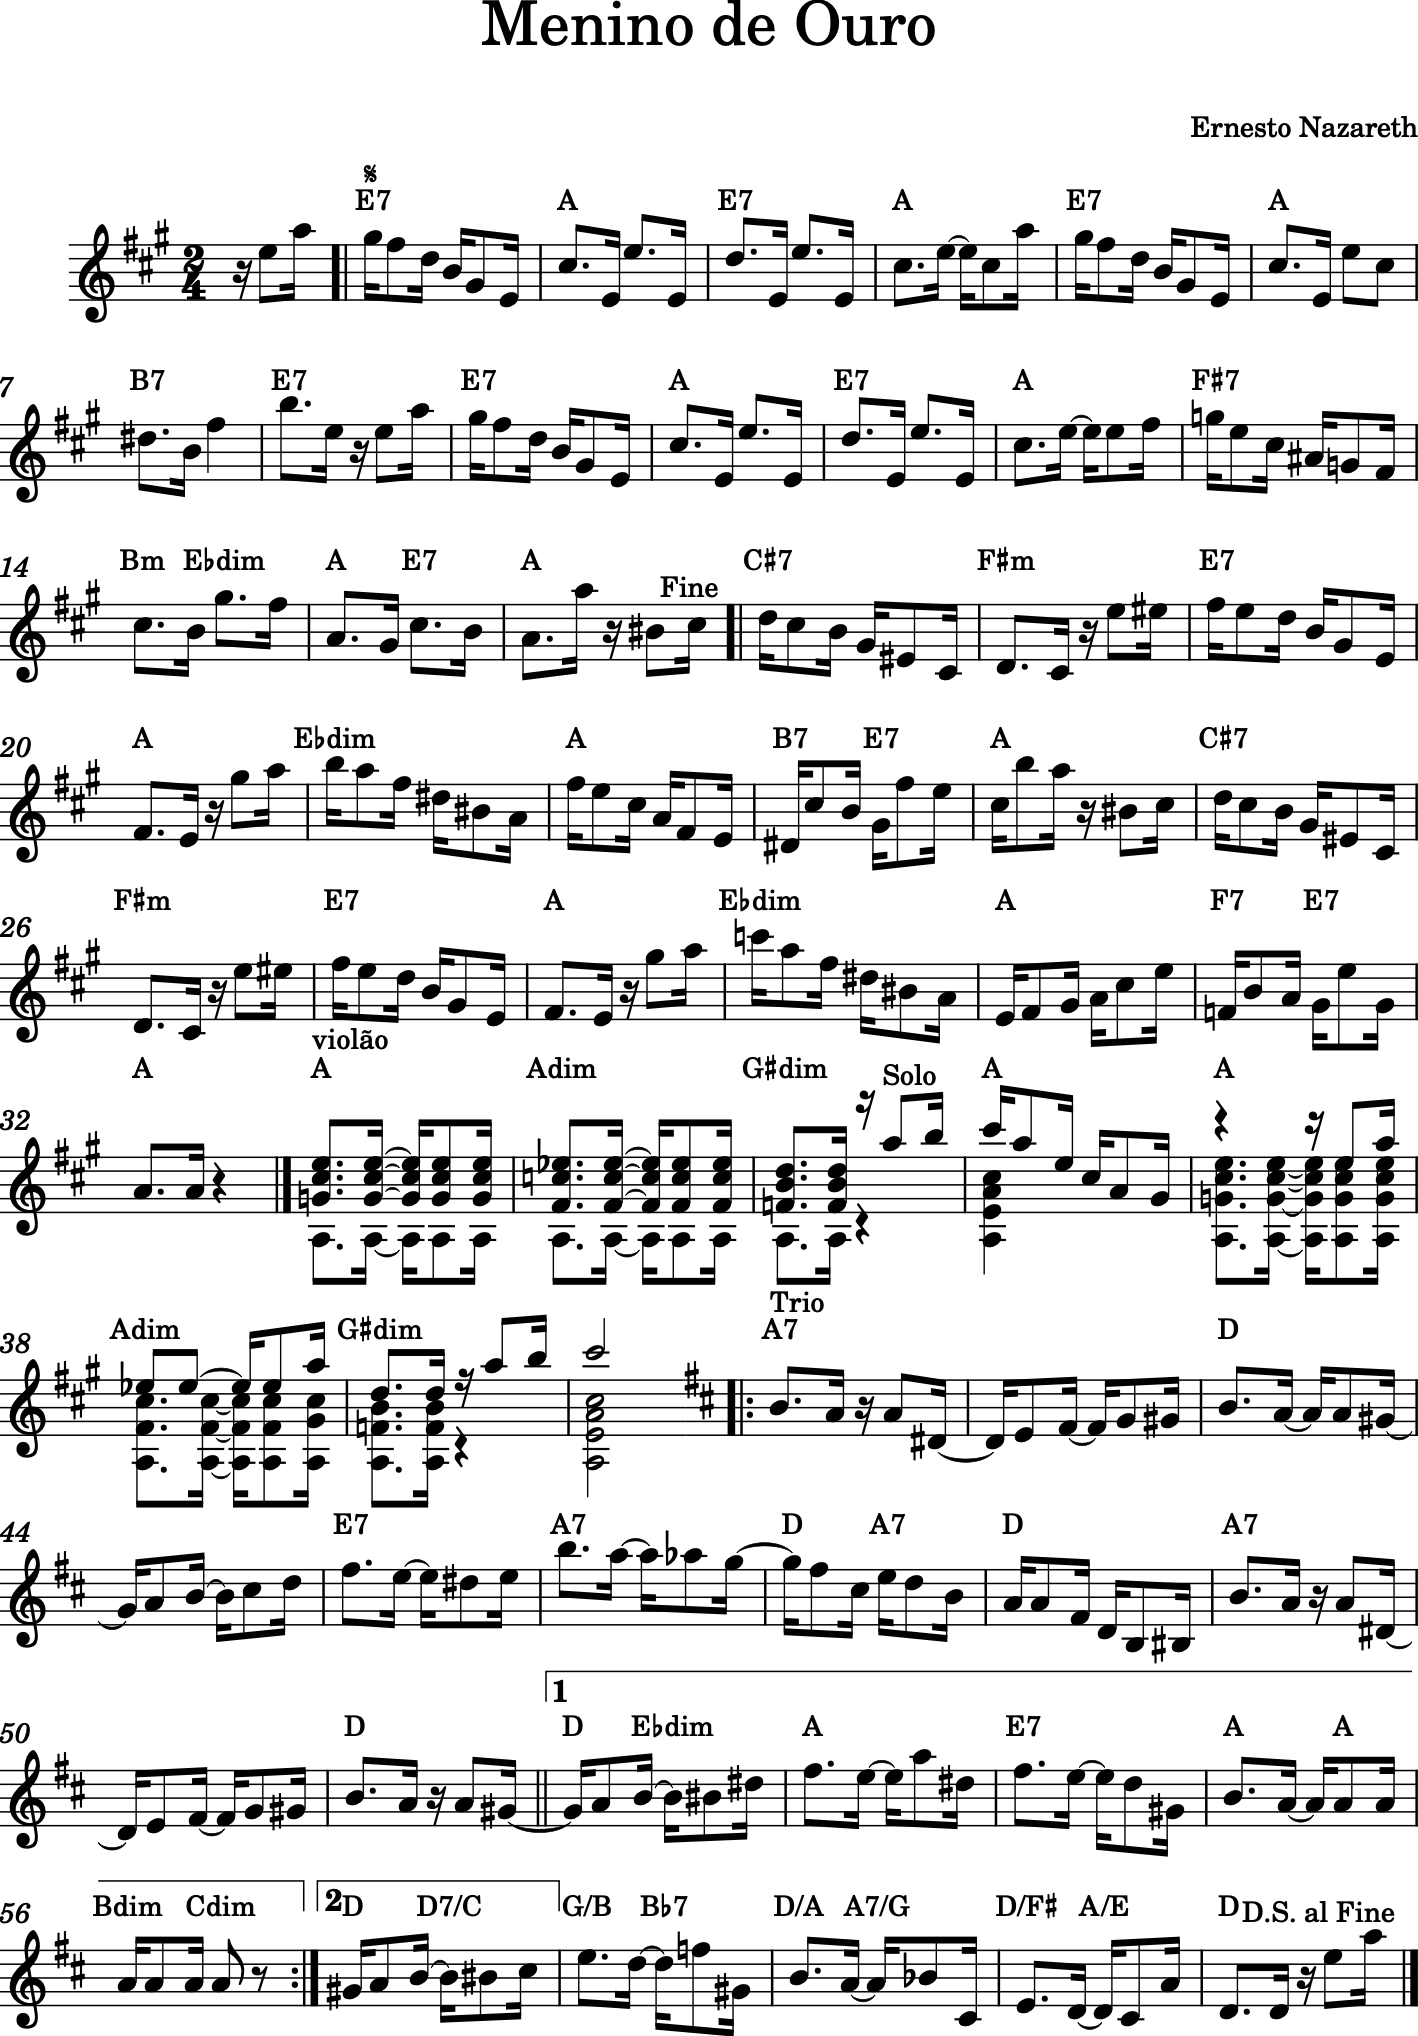

In [10]:
score.show()